# Twitter Sentiment Anlysis

## Environment Setup

In [138]:
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns

## Config

In [139]:
RANDOM_STATE = 2
LEARNING_RATE = 0.01
EPOCHS = 200
BATCH_SIZE = 128
VAL_SPLIT = 0.2
TEST_SPLIT = 0.125

## Dataset Loading & EDA

In [140]:
raw_df = pd.read_csv('data/sentiment_analysis.csv')
raw_df.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


In [141]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7920 entries, 0 to 7919
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      7920 non-null   int64
 1   label   7920 non-null   int64
 2   tweet   7920 non-null   str  
dtypes: int64(2), str(1)
memory usage: 1.2 MB


In [142]:
raw_df.describe()

,id,label
count,7920.000000,7920.000000
mean,3960.500000,0.255808
std,2286.451399,0.436342
min,1.000000,0.000000
25%,1980.750000,0.000000
50%,3960.500000,0.000000
75%,5940.250000,1.000000
max,7920.000000,1.000000


## Dataset Split

In [143]:
df = raw_df.drop(columns=['id'])
df.head()

,label,tweet
0,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,0,Finally a transparant silicon case ^^ Thanks t...
2,0,We love this! Would you go? #talk #makememorie...
3,0,I'm wired I know I'm George I was made that wa...
4,1,What amazing service! Apple won't even talk to...


In [144]:
X, y = df['tweet'].to_numpy(), df['label'].to_numpy()


X_trainval, X_val, y_trainval, y_val = train_test_split(X, y, test_size=VAL_SPLIT, stratify=y, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(X_trainval, y_trainval, test_size=TEST_SPLIT, stratify=y_trainval, random_state=RANDOM_STATE)

In [145]:
print(f"Train size: {len(X_train) / len(X) * 100:.1f}%")
print(f"Val size:   {len(X_val) / len(X) * 100:.1f}%")
print(f"Test size:  {len(X_test) / len(X) * 100:.1f}%")

Train size: 70.0%
Val size:   20.0%
Test size:  10.0%


## Data Preprocessing

### Cleaning and Tokenization

In [146]:
def clean_data(X):
    cleaned = []

    rules = [
        (r'^RT\s+', ''),
        (r'https?://\S+', ''),
        (r'@\w+', ''),
        (r'#', ''),
        (r'[^\w\s]', '')
    ]

    for tweet in X:      
        for pattern, replacement in rules:
            tweet = re.sub(pattern, replacement, tweet)

        tokens = [x for x in tweet.lower().strip().split()]

        cleaned.append(tokens)

    return cleaned

In [147]:
train_tokens = clean_data(X_train)
val_tokens = clean_data(X_val)
test_tokens = clean_data(X_test)

### Frequency Dictionary

In [148]:
freqs = {}

for tokens, label in zip(train_tokens, y_train):
    for word in tokens:
        key = (word, label)
        freqs[key] = freqs.get(key, 0) + 1

### Vectorization

In [149]:
def extract_features(tokens, freqs):
    neg = sum(freqs.get((word, 1), 0) for word in tokens)
    pos = sum(freqs.get((word, 0), 0) for word in tokens)
    return [1, neg, pos]

In [150]:
X_train = np.array([extract_features(tokens, freqs) for tokens in train_tokens], dtype=float)
X_val = np.array([extract_features(tokens, freqs) for tokens in val_tokens], dtype=float)
X_test = np.array([extract_features(tokens, freqs) for tokens in test_tokens], dtype=float)

### Normalization

In [151]:
scaler = StandardScaler()

X_train[:, 1:] = scaler.fit_transform(X_train[:, 1:])
X_val[:, 1:] = scaler.transform(X_val[:, 1:])
X_test[:, 1:] = scaler.transform(X_test[:, 1:])

## Helper Functions

In [152]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [153]:
def predict(X, theta):

    logits = X @ theta

    y_hat = sigmoid(logits)

    return y_hat

In [154]:
def compute_loss(y_pred, y_true):

    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)

    loss = np.mean(-y_true * np.log(y_pred) - (1 - y_true) * np.log(1 - y_pred))

    return loss

In [155]:
def compute_gradient(X, y_true, y_pred):

    gradient = (X.T @ (y_pred - y_true)) / len(X) 

    return gradient

In [156]:
def update_theta(theta, gradient, lr):
    return theta - lr * gradient

In [157]:
def compute_accuracy(y_pred, y_true):

    preds = np.round(y_pred, 0)
    correct = np.sum(y_true == preds)

    accuracy = correct / y_true.shape[0]

    return accuracy

## Training Loop

In [158]:
theta = np.zeros(X_train.shape[1])
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(EPOCHS):

    perm = np.random.permutation(len(X_train))
    X_shuffled = X_train[perm]
    y_shuffled = y_train[perm]

    for start in range(0, len(X_shuffled), BATCH_SIZE):

        X_batch = X_shuffled[start : start+BATCH_SIZE]
        y_batch = y_shuffled[start : start+BATCH_SIZE]

        y_hat_batch = predict(X_batch, theta)
        grad = compute_gradient(X_batch, y_batch, y_hat_batch)
        theta = update_theta(theta, grad, LEARNING_RATE)
    
    train_loss = compute_loss(predict(X_train, theta), y_train)
    val_loss = compute_loss(predict(X_val, theta), y_val)
    train_acc = compute_accuracy(predict(X_train, theta), y_train)
    val_acc = compute_accuracy(predict(X_val, theta), y_val)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)


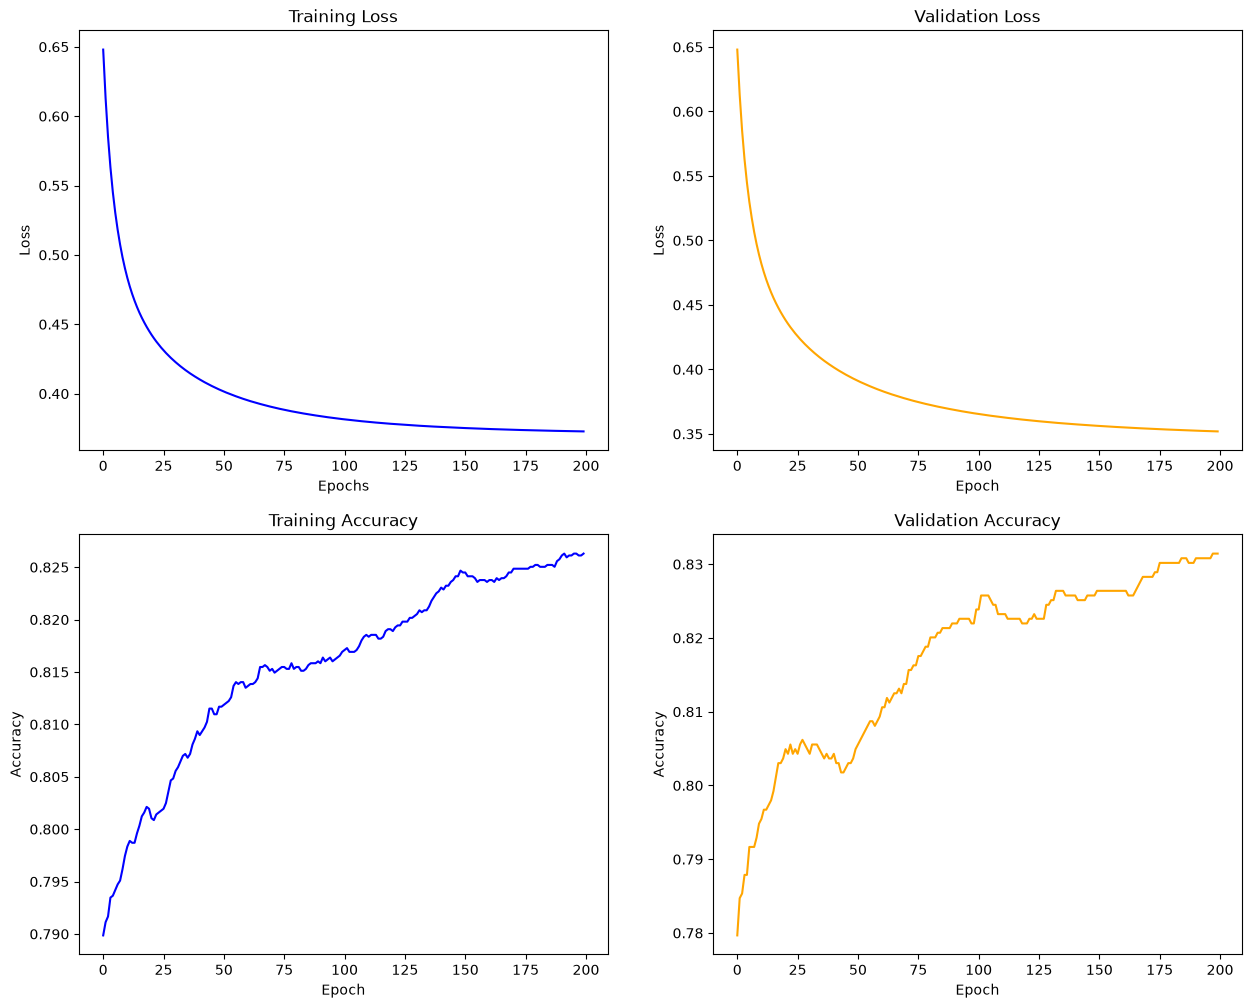

In [159]:
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15, 12))

ax1[0].plot(train_losses, color='blue')
ax1[0].set_title('Training Loss')
ax1[0].set_xlabel('Epochs')
ax1[0].set_ylabel('Loss')

ax1[1].plot(val_losses, color='orange')
ax1[1].set_title('Validation Loss')
ax1[1].set_xlabel('Epoch')
ax1[1].set_ylabel('Loss')

ax2[0].plot(train_accs, color='blue')
ax2[0].set_title('Training Accuracy')
ax2[0].set_xlabel('Epoch')
ax2[0].set_ylabel('Accuracy')

ax2[1].plot(val_accs, color='orange')
ax2[1].set_title('Validation Accuracy')
ax2[1].set_xlabel('Epoch')
ax2[1].set_ylabel('Accuracy')


plt.show()
